# 05 · Pareto frontier, maps and sensitivity

**Goal:** explore the full range of trade-offs between distance and CO₂, map the two extreme plans on real roads, and test how much the result depends on the load assumption.

### Setup and helpers
Same data, evaluator, payload tracker and CVRP solver as Notebook 4 (with a shorter 3 s time limit, since it runs many times). `TERRAIN_SCALE` must match Notebook 4.

- `co2_matrix` gives the CO₂ (kg) of every arc for a given payload estimate.
- `solve_blended(lam, payloads)` solves with a cost that mixes distance and CO₂ (explained below).

In [1]:
!pip install -q polyline

import os

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polyline
import requests
from ortools.constraint_solver import pywrapcp, routing_enums_pb2

import emissions

CITY = os.environ.get("EMROUTE_CITY", "dhaka")
DATA_DIR, OUT_DIR = "../data", "../outputs"

stops = pd.read_csv(f"{DATA_DIR}/stops_{CITY}.csv")
distance_m = pd.read_csv(f"{DATA_DIR}/distance_m_{CITY}.csv").values
duration_s = pd.read_csv(f"{DATA_DIR}/duration_s_{CITY}.csv").values

n = len(stops)
demands = stops["demand_kg"].values

NUM_VEHICLES = 3
CAPACITY_KG = 600
DEPOT = 0

# 1.0 = real terrain. Larger values exaggerate relief for a "what if it were hillier" test.
TERRAIN_SCALE = 1.0
elevation = stops["elevation_m"].values * TERRAIN_SCALE

# climb_m[i, j] = metres gained driving from i to j (0 if downhill)
climb_m = np.maximum(elevation[None, :] - elevation[:, None], 0)


def arcs_with_payload(route, demand):
    """Yield (i, j, payload) for each arc i -> j of a route.

    payload = weight on board while driving i -> j. The van leaves the depot
    with every parcel for the route and drops j's parcel on arrival at j.
    """
    payload = sum(demand[node] for node in route)
    for i, j in zip(route, route[1:]):
        yield i, j, payload
        payload -= demand[j]


def evaluate(routes):
    """Total distance (km) and true CO2 (kg) of a set of routes."""
    total_distance_m = 0.0
    total_co2 = 0.0
    for route in routes:
        for i, j, payload in arcs_with_payload(route, demands):
            total_distance_m += distance_m[i][j]
            total_co2 += emissions.co2_kg(distance_m[i][j], duration_s[i][j], payload, climb_m[i][j])
    return total_distance_m / 1000.0, total_co2


def payload_leaving_each_node(routes):
    """Payload on board as the van departs each node, as a list indexed by node."""
    payloads = [0] * n
    for route in routes:
        for i, _, payload in arcs_with_payload(route, demands):
            payloads[i] = payload
    return payloads


def solve_cvrp(cost_matrix, time_limit_s=3):
    """Solve the capacitated VRP for any integer cost matrix. Returns a list of routes."""
    # OR-Tools has its own internal indices; manager.IndexToNode() maps them to our nodes.
    manager = pywrapcp.RoutingIndexManager(n, NUM_VEHICLES, DEPOT)
    routing = pywrapcp.RoutingModel(manager)

    # Arc cost depends only on (from, to): OR-Tools cannot see the van's current load.
    def cost_callback(from_index, to_index):
        return cost_matrix[manager.IndexToNode(from_index)][manager.IndexToNode(to_index)]

    routing.SetArcCostEvaluatorOfAllVehicles(routing.RegisterTransitCallback(cost_callback))

    # Capacity: the demand served on one route must fit in one van.
    def demand_callback(from_index):
        return int(demands[manager.IndexToNode(from_index)])

    routing.AddDimensionWithVehicleCapacity(
        routing.RegisterUnaryTransitCallback(demand_callback),
        0,                              # no slack
        [CAPACITY_KG] * NUM_VEHICLES,   # capacity of each van
        True,                           # every van starts empty
        "Capacity",
    )

    # Greedy first solution, then improve it with guided local search.
    params = pywrapcp.DefaultRoutingSearchParameters()
    params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    params.time_limit.FromSeconds(time_limit_s)

    solution = routing.SolveWithParameters(params)
    if solution is None:
        raise RuntimeError("No solution found -- check capacity vs demand.")

    routes = []
    for vehicle in range(NUM_VEHICLES):
        index = routing.Start(vehicle)
        route = []
        while not routing.IsEnd(index):
            route.append(manager.IndexToNode(index))
            index = solution.Value(routing.NextVar(index))
        route.append(manager.IndexToNode(index))   # back at the depot

        if len(route) > 2:                         # skip vans that never left the depot
            routes.append(route)

    return routes


def co2_matrix(payload_leaving):
    """CO2 (kg) of every arc i -> j, given the payload leaving each node."""
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                matrix[i][j] = emissions.co2_kg(
                    distance_m[i][j], duration_s[i][j], payload_leaving[i], climb_m[i][j]
                )
    return matrix


d_norm = distance_m / distance_m.max()   # distance scaled to 0-1


def solve_blended(lam, payload_leaving):
    """Solve with cost = (1 - lam) * distance + lam * CO2, both scaled to 0-1."""
    c = co2_matrix(payload_leaving)
    blended = (1 - lam) * d_norm + lam * (c / c.max())
    return solve_cvrp(np.round(blended * 1_000_000).astype(np.int64))


print("Helpers ready.")

Helpers ready.


### Weighted-sum sweep
Both objectives are blended with a weight $\lambda$:

$$\text{cost}_{ij} = (1-\lambda)\,\frac{d_{ij}}{\max d} + \lambda\,\frac{c_{ij}}{\max c}$$

$\lambda = 0$ is pure distance, $\lambda = 1$ is pure CO₂. Each matrix is divided by its maximum so both lie in $[0, 1]$; otherwise metres (~10⁴ per arc) would swamp kilograms (~1 per arc). The blend is multiplied by 10⁶ and rounded for OR-Tools.

$\lambda$ is sampled densely on 0–0.30 (16 points), where the plan changes most, and coarsely on 0.35–1.0 (8 points). At each $\lambda$, 3 rounds of payload re-costing are run and **every** iterate is kept as a candidate. Duplicate plans are then dropped.

In [2]:
# Sample lambda finely near 0, where the plan changes, and coarsely after that.
lambdas = sorted(set(
    [round(x, 4) for x in np.linspace(0.0, 0.30, 16)] +
    [round(x, 4) for x in np.linspace(0.35, 1.0, 8)]
))

candidates = []

for lam in lambdas:
    payload_est = [demands.sum() / NUM_VEHICLES] * n   # first guess: an even split

    for _ in range(3):   # payload re-costing rounds, as in Notebook 4
        routes = solve_blended(lam, payload_est)
        d, c = evaluate(routes)
        candidates.append({"lambda": lam, "distance_km": d, "co2_kg": c, "routes": routes})
        payload_est = payload_leaving_each_node(routes)

    print(f"  lambda={lam:.3f}  ->  {d:6.2f} km   {c:.3f} kg CO2")

# Many lambdas lead to the same plan; keep one copy of each.
sweep = pd.DataFrame(candidates)
sweep = sweep.drop_duplicates(subset=["distance_km", "co2_kg"]).reset_index(drop=True)
print()
print(f"{len(sweep)} distinct candidate solutions generated.")

  lambda=0.000  ->   76.86 km   43.219 kg CO2


  lambda=0.020  ->   76.86 km   43.219 kg CO2


  lambda=0.040  ->   76.86 km   43.219 kg CO2


  lambda=0.060  ->   76.86 km   43.219 kg CO2


  lambda=0.080  ->   76.86 km   43.219 kg CO2


...

  lambda=0.629  ->   76.96 km   43.042 kg CO2


  lambda=0.721  ->   76.96 km   43.042 kg CO2


  lambda=0.814  ->   76.96 km   43.042 kg CO2


  lambda=0.907  ->   76.96 km   43.042 kg CO2


  lambda=1.000  ->   76.96 km   43.042 kg CO2

3 distinct candidate solutions generated.


### Pareto filter
A plan is **dominated** if another plan is at least as good on both distance and CO₂. Only non-dominated plans form the frontier.

One-pass method: sort by distance, then keep a plan only if its CO₂ is lower than every plan before it.

The frontier's two ends are the min-distance plan (A) and the min-CO₂ plan (B); the trade-off is computed the same way as in Notebook 4.

In [3]:
def pareto_front(df):
    """Keep only plans that no other plan beats on both distance and CO2.

    Sorted by distance, a plan is kept only if its CO2 is lower than every plan before it.
    """
    front, best_co2 = [], float("inf")
    for _, row in df.sort_values("distance_km").iterrows():
        if row["co2_kg"] < best_co2 - 1e-9:
            front.append(row)
            best_co2 = row["co2_kg"]
    return pd.DataFrame(front)


front = pareto_front(sweep)

dist_A, co2_A = front.iloc[0]["distance_km"], front.iloc[0]["co2_kg"]     # min distance
dist_B, co2_B = front.iloc[-1]["distance_km"], front.iloc[-1]["co2_kg"]   # min CO2

print(f"{len(front)} of {len(sweep)} solutions are non-dominated\n")
print(f"Cheapest distance : {dist_A:.2f} km, {co2_A:.3f} kg")
print(f"Lowest CO2        : {dist_B:.2f} km, {co2_B:.3f} kg")
print(f"\n>>> {100*(dist_B/dist_A - 1):+.1f}% distance buys "
      f"{100*(1 - co2_B/co2_A):.1f}% less CO2 <<<")

2 of 3 solutions are non-dominated

Cheapest distance : 76.86 km, 43.219 kg
Lowest CO2        : 76.96 km, 43.042 kg

>>> +0.1% distance buys 0.4% less CO2 <<<


### Plot the frontier
Grey dots = dominated candidates, blue line = Pareto frontier, orange circles = the two endpoints. Saved to `outputs/pareto_{city}.png`.

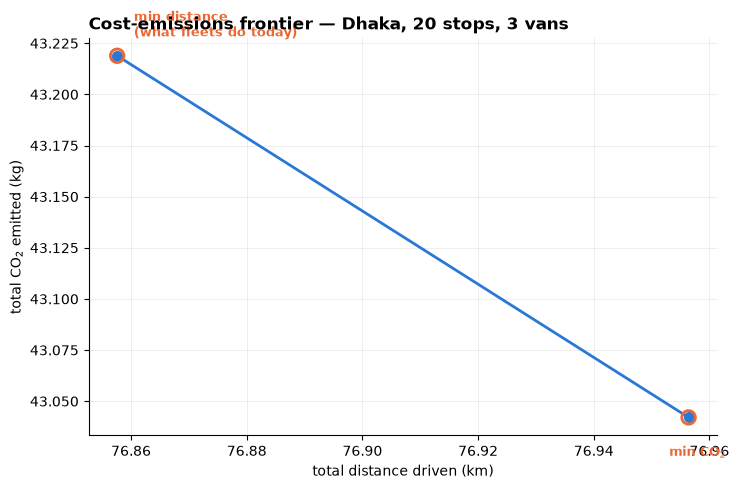

In [4]:
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#9a9a94"

fig, ax = plt.subplots(figsize=(7.5, 5))

dominated = sweep[~sweep.index.isin(front.index)]
ax.scatter(dominated["distance_km"], dominated["co2_kg"], s=38, color=GREY, alpha=0.55, zorder=2)

ax.plot(front["distance_km"], front["co2_kg"], color=BLUE, lw=2, marker="o", ms=7, zorder=3)

# Label the two endpoints directly
ax.annotate("min distance\n(what fleets do today)",
            (dist_A, co2_A), xytext=(12, 14), textcoords="offset points",
            color=ORANGE, fontsize=9, fontweight="bold")
ax.annotate("min CO$_2$", (dist_B, co2_B), xytext=(-14, -28),
            textcoords="offset points", color=ORANGE, fontsize=9, fontweight="bold")
ax.scatter([dist_A, dist_B], [co2_A, co2_B], s=95, facecolor="none",
           edgecolor=ORANGE, lw=2, zorder=4)

ax.set_xlabel("total distance driven (km)")
ax.set_ylabel("total CO$_2$ emitted (kg)")
ax.set_title(f"Cost-emissions frontier — {CITY.title()}, {n-1} stops, "
             f"{NUM_VEHICLES} vans", loc="left", fontweight="bold")
ax.grid(alpha=0.25, lw=0.6)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(f"{OUT_DIR}/pareto_{CITY}.png", dpi=150, bbox_inches="tight")
plt.show()

### Route maps
`road_geometry` asks OSRM's `route` service for the actual road path through a route's stops (returned as a compressed polyline and decoded), so lines follow the streets instead of cutting straight across.

`draw_map` draws each van in a fixed colour and numbers its stops in visit order. This makes the load effect visible: in a CO₂-optimal plan, heavy stops should tend to get low numbers. One map is saved for plan A and one for plan B. The last line redraws map B so it shows as the cell's output.

In [5]:
ESRI = ("https://server.arcgisonline.com/ArcGIS/rest/services/"
        "Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}")

VAN_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]   # van 1, 2, 3 -- same on both maps


def road_geometry(route):
    """(lat, lon) points of the actual road path through a route's stops, from OSRM."""
    coords = ";".join(f"{stops.loc[i,'lon']},{stops.loc[i,'lat']}" for i in route)
    r = requests.get(f"https://router.project-osrm.org/route/v1/driving/{coords}",
                     params={"overview": "full", "geometries": "polyline"}, timeout=60)
    r.raise_for_status()
    return polyline.decode(r.json()["routes"][0]["geometry"])


def draw_map(routes, title, filename):
    m = folium.Map(location=[stops.loc[0, "lat"], stops.loc[0, "lon"]],
                   zoom_start=12, tiles=ESRI, attr="Tiles © Esri")

    for v, route in enumerate(routes):
        color = VAN_COLORS[v % len(VAN_COLORS)]
        load = sum(demands[i] for i in route)

        folium.PolyLine(road_geometry(route), color=color, weight=4, opacity=0.85,
                        tooltip=f"Van {v+1} — {load:.0f} kg").add_to(m)

        # Number each stop by its position in the route.
        for order, node in enumerate(route[1:-1], start=1):
            folium.Marker(
                [stops.loc[node, "lat"], stops.loc[node, "lon"]],
                icon=folium.DivIcon(html=(
                    f'<div style="background:{color};color:#fff;border-radius:50%;'
                    f'width:22px;height:22px;line-height:22px;text-align:center;'
                    f'font:bold 11px sans-serif">{order}</div>')),
                popup=f"{stops.loc[node,'address'].split(',')[0]} — "
                      f"{demands[node]:.0f} kg (stop {order})",
            ).add_to(m)

    folium.Marker([stops.loc[0, "lat"], stops.loc[0, "lon"]], popup="DEPOT",
                  icon=folium.Icon(color="red", icon="home")).add_to(m)

    # Title box in the top-left corner
    folium.Marker(
        [stops["lat"].max(), stops["lon"].min()],
        icon=folium.DivIcon(html=f'<div style="font:bold 15px sans-serif;'
                                 f'background:#fff;padding:6px 10px">{title}</div>')
    ).add_to(m)

    m.save(f"{OUT_DIR}/{filename}")
    return m


routes_A, routes_B = front.iloc[0]["routes"], front.iloc[-1]["routes"]

draw_map(routes_A, f"Min distance — {dist_A:.1f} km, {co2_A:.2f} kg CO₂",
         f"routes_distance_{CITY}.html")
map_B = draw_map(routes_B, f"Min CO₂ — {dist_B:.1f} km, {co2_B:.2f} kg CO₂",
                 f"routes_co2_{CITY}.html")

print("Saved both route maps to outputs/")
map_B

Saved both route maps to outputs/


### Sensitivity to `LOAD_SENSITIVITY`
The +25% full-load fuel penalty is an assumption. The pure-CO₂ problem ($\lambda = 1$) is re-solved for values from 0.10 to 0.40 (temporarily overriding the module constant), and each result is compared with the **same** min-distance routes A, re-scored under that value:

$$\text{CO}_2\ \text{saved} = 100\left(1 - \frac{C_{\text{CO}_2\,\text{plan}}}{C_A}\right)\%, \qquad \Delta\text{distance} = 100\left(\frac{D_{\text{CO}_2\,\text{plan}}}{D_A} - 1\right)\%$$

If the savings stay small across the whole range, the conclusion doesn't hinge on this parameter. The original value is restored afterwards.

In [6]:
original = emissions.LOAD_SENSITIVITY
rows = []

for value in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40]:
    emissions.LOAD_SENSITIVITY = value   # temporarily change the model

    payload_est = [demands.sum() / NUM_VEHICLES] * n
    for _ in range(3):
        routes = solve_blended(1.0, payload_est)   # pure CO2
        payload_est = payload_leaving_each_node(routes)

    d_s, c_s = evaluate(routes)
    _, c_base = evaluate(routes_A)   # min-distance plan, re-scored with this value
    rows.append({"load_sensitivity": value,
                 "co2_saved_pct": round(100 * (1 - c_s / c_base), 2),
                 "extra_distance_pct": round(100 * (d_s / dist_A - 1), 2)})

emissions.LOAD_SENSITIVITY = original   # always restore

sensitivity = pd.DataFrame(rows)
sensitivity.to_csv(f"{DATA_DIR}/sensitivity_{CITY}.csv", index=False)
print("How much does the headline result depend on LOAD_SENSITIVITY?\n")
sensitivity

How much does the headline result depend on LOAD_SENSITIVITY?



,load_sensitivity,co2_saved_pct,extra_distance_pct
0,0.10,0.42,0.13
1,0.15,0.42,0.13
2,0.20,0.41,0.13
3,0.25,0.41,0.13
4,0.30,0.41,0.13
5,0.40,0.40,0.13


### Save and summarise
Frontier → `pareto_{city}.csv`, all candidates → `sweep_{city}.csv`, plus a printed summary of the headline result.

In [7]:
front.drop(columns=["routes"]).to_csv(f"{DATA_DIR}/pareto_{CITY}.csv", index=False)
sweep.drop(columns=["routes"]).to_csv(f"{DATA_DIR}/sweep_{CITY}.csv", index=False)

print(f"""
RESULTS — {CITY.title()}
  stops                {n-1}
  vans                 {NUM_VEHICLES} x {CAPACITY_KG} kg
  min-distance plan    {dist_A:.2f} km   {co2_A:.3f} kg CO2
  min-CO2 plan         {dist_B:.2f} km   {co2_B:.3f} kg CO2
  trade-off            {100*(dist_B/dist_A-1):+.1f}% distance -> {100*(1-co2_B/co2_A):.1f}% CO2
  frontier points      {len(front)}
""")


RESULTS — Dhaka
  stops                20
  vans                 3 x 600 kg
  min-distance plan    76.86 km   43.219 kg CO2
  min-CO2 plan         76.96 km   43.042 kg CO2
  trade-off            +0.1% distance -> 0.4% CO2
  frontier points      2



## Conclusions

- **The frontier barely exists.** Dhaka has just 2 non-dominated plans (the two from Notebook 4), and the switch happens around $\lambda \approx 0.2$. Sylhet has a single plan that is best on both objectives at every $\lambda$.
- **The maps show how little changes:** the two Dhaka maps are identical except for three neighbouring stops on van 2, reversed so that the heaviest parcel (54 kg) is dropped first. That is the only place where the load effect is worth the extra 99 m. Everywhere else, no detour pays for itself.
- **The result is robust to the load assumption.** Varying `LOAD_SENSITIVITY` from 0.10 to 0.40 keeps Dhaka's saving between 0.40% and 0.42% (always for +0.13% distance), and Sylhet's at 0.00%.
- **Why the trade-off is so small:** distance and CO₂ are almost perfectly correlated arc by arc. Congestion is a single factor per city, the terrain is flat, and the load effect is at most 25%, so the cheapest route in kilometres is also (almost) the cheapest in carbon.

### Overall conclusion
For last-mile delivery in Bangladeshi cities, **routing for carbon instead of distance buys essentially nothing**: 0.41% in Dhaka and 0% in Sylhet. Fleets should keep minimising distance. The real carbon levers are elsewhere: vehicle choice, load consolidation and electrification.

**Caveats:** the weighted-sum sweep can miss concave parts of the frontier, elevation is known only at the stops (gradient cost is understated), and congestion is one number per city. These results describe two case studies, not every city.